# 실습 : Oxford-IIIT Pet 데이터셋 - Transfer Learning 활용

강아지 / 고양이 binary classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, "/ device:", device)

2.11.0+cu128 / device: cuda


## 데이터셋 다운로드
### category(품종) 레이블을 고양이(0) / 개(1)로 변환해 사용


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
transforms.Resize((256, 256)),
transforms.RandomCrop(224),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

eval_transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

### Train / Test 분리

In [3]:
def binary_target(y):
  return 0 if y < 12 else 1


train_full = OxfordIIITPet(
    root="data", split="trainval", target_types="category",
    target_transform=binary_target,
    transform=train_transform, download=True
    )

test_set = OxfordIIITPet(
    root="data", split="test", target_types="category",
    target_transform=binary_target,
    transform=eval_transform, download=True
    )

### Train / Validation 분리

In [4]:
n_val = int(len(train_full) * 0.2)
train_set, val_set = random_split(train_full,
[len(train_full) - n_val, n_val])
print(len(train_set), len(val_set), len(test_set))

2944 736 3669


### Data Loader 구성
배치 단위 로딩·셔플·병렬 전처리를 담당 — 학습 루프의 데이터 공급 파이프라인

In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
shuffle=True, num_workers=0, pin_memory=True)

val_loader = DataLoader(val_set, batch_size=BATCH_SIZE,
shuffle=False, num_workers=0, pin_memory=True)

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE,
shuffle=False, num_workers=0, pin_memory=True)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels[:8])

torch.Size([32, 3, 224, 224])
tensor([1, 1, 1, 0, 1, 1, 1, 1])


### 샘플 이미지 확인

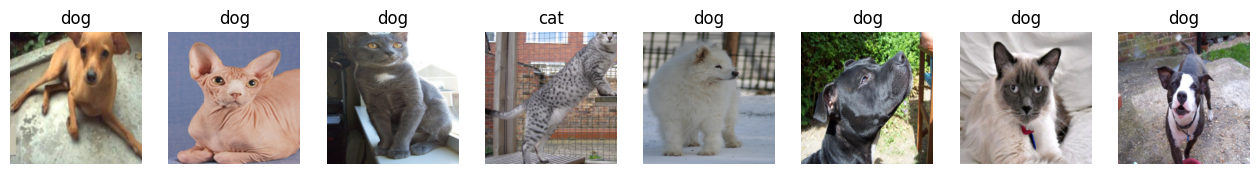

In [6]:
CLASSES = ["cat", "dog"]

def show_batch(images, labels, n=8):
  mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
  std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
  plt.figure(figsize=(16, 4))

  for i in range(n):
    img = (images[i] * std + mean).clamp(0, 1)
    plt.subplot(1, n, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(CLASSES[labels[i]]); plt.axis("off")
  plt.show()

show_batch(images, labels)

## Transfer Learning

### ResNet50 (사전학습됨) 불러오기

In [7]:
from torchvision import models

weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

# 마지막 완전연결층(fc)을 우리 문제(2클래스)에 맞게 교체
num_features = model.fc.in_features # 2048
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


Linear(in_features=2048, out_features=2, bias=True)


fc 했는데 없으면 print(model) 해서 마지막에 나오는 애 이름 쓰기

### 특징 추출

In [8]:
for param in model.parameters():
  param.requires_grad = False

# 새로 교체한 분류기만 학습 대상으로 (새 층은 기본 True)
model.fc = nn.Linear(num_features, 2).to(device)

# 학습되는 파라미터 수 확인
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"학습 대상: {trainable:,} / 전체: {total:,}")
# 0.02%만 학습

학습 대상: 4,098 / 전체: 23,512,130


### 학습 및 평가 함수 정의

In [9]:
def train_one_epoch(model, loader, criterion=None, optimizer=None):
  if criterion is None:
    criterion = nn.CrossEntropyLoss()
  model.train()
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    loss = criterion(model(x), y)
    loss.backward()
    optimizer.step()

@torch.no_grad()
def evaluate(model, loader):
  model.eval(); correct = total = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    pred = model(x).argmax(dim=1)
    correct += (pred == y).sum().item(); total += len(y)
  return correct / total

### 통합 학습 함수 정의

In [10]:
def train_model(model, train_loader, val_loader, epochs=1, criterion=None, optimizer=None, verbose=True):
  if criterion is None:
    criterion = nn.CrossEntropyLoss()
  if optimizer is None:
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)
  for epoch in range(epochs):
    train_one_epoch(model, train_loader, criterion, optimizer)
    if verbose:
      print(f" epoch {epoch+1}: val_acc = " f"{evaluate(model, val_loader):.4f}")
  return model

### 분류기 파라미터만 optimizer에 전달

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

for epoch in range(1): # 시연용 1 에폭 (성능을 보려면 3 이상 권장)
  train_one_epoch(model, train_loader, criterion, optimizer)
  acc = evaluate(model, val_loader)
  print(f"epoch {epoch+1}: val_acc = {acc:.4f}")

print(f"test_acc = {evaluate(model, test_loader):.4f}")

epoch 1: val_acc = 0.8438
test_acc = 0.8536


### Fine Tuning (미세조정)
깊은 층일수록 문제 특화 특징 → 마지막 블록(layer4)부터 낮은 학습률로 재학습

In [12]:
# 마지막 블록(layer4)과 분류기(fc)만 다시 학습
for name, param in model.named_parameters():
  param.requires_grad = ("layer4" in name or "fc" in name)

# 차등 학습률: backbone은 작게, 분류기는 크게
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4}
])

for epoch in range(1): # 시연용 1 에폭
  train_one_epoch(model, train_loader, criterion, optimizer)
  print(f"val_acc = {evaluate(model, val_loader):.4f}")

val_acc = 0.8668


## 모델 정의

In [13]:
def create_model(name, num_classes=2):
  if name == "resnet50":
    m = models.resnet50(weights="IMAGENET1K_V2")
    m.fc = nn.Linear(m.fc.in_features, num_classes)

  elif name == "vgg16": # 6.1절의 VGGNet
    m = models.vgg16(weights="IMAGENET1K_V1")
    m.classifier[6] = nn.Linear(4096, num_classes)

  elif name == "googlenet": # 6.1절의 GoogLeNet
    m = models.googlenet(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, num_classes)

  return m.to(device)

model = create_model("vgg16")
print(type(model).__name__)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 74.5MB/s]


VGG
